Step 1: Load and Preprocess the Data

Load the dataset and apply the necessary preprocessing steps. Note that proper feature scaling (e.g., standardizing the data) is a critical mathematical requirement for ensuring the correctness of PCA.

In [29]:
import csv
import numpy as np

import pandas as pd
pd.set_option('display.notebook_repr_html', False)

from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA 
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn import metrics
from sklearn.metrics import homogeneity_score

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

X_featureNames = []
y_featureNames = []

with open("UCIDataset/features.txt", "r") as dataset:
    featureReader = csv.reader(dataset, delimiter=' ')
    for line in featureReader:
        X_featureNames.append(line[1])

with open("UCIDataset/train/X_train.txt", "r") as dataset:
    df = pd.read_csv(dataset, delimiter=r'\s+', header=None, names=X_featureNames)
    X_trainData = df.to_dict(orient='records')
    X_train = df.to_numpy()
    # for i in X_trainData:
    #     print(i)

with open("UCIDataset/test/X_test.txt", "r") as dataset:
    df = pd.read_csv(dataset, delimiter=r'\s+', header = None, names=X_featureNames)
    X_testData = df.to_dict(orient='records')
    X_test = df.to_numpy()
    # for i in X_testData:
    #     print(i)

with open("UCIDataset/activity_labels.txt", "r") as dataset:
    featureReader = csv.reader(dataset, delimiter=' ')
    for line in featureReader:
        y_featureNames.append(line[1])

with open("UCIDataset/train/y_train.txt", "r") as dataset:
    # df = pd.read_csv(dataset, header=None)
    # print(df)
    df = dataset.read().splitlines()
    y_train = [int(x) for x in df]
    # for i in y_trainData:
    # print(y_train)

with open("UCIDataset/test/y_test.txt", "r") as dataset:
    df = dataset.read().splitlines()
    y_test = [int(x) for x in df]

# Training data can be used for PCA
# Testing data can be used for k-means clustering

Step 2: Dimensionality Reduction

Use Principal Component Analysis (PCA) to reduce the dimensionality of your dataset (Visualize the 2D projection, coloring the data points by their true activity labels to establish a visual baseline):

Extract 2 components for 2D visualization:

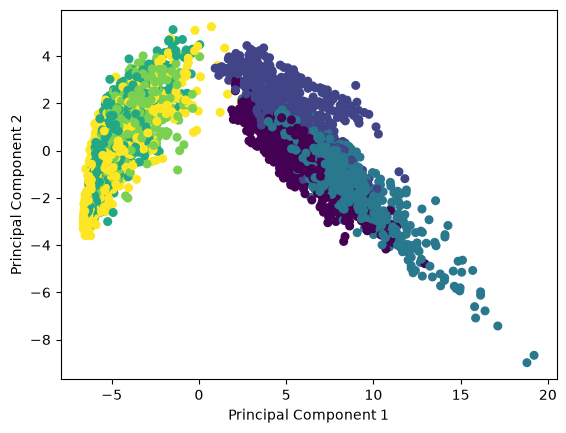

In [30]:
pca_model = PCA()
X_PCA = pca_model.fit_transform(X_train)

plt.scatter( X_PCA[:, 0], X_PCA[:, 1], c=y_train, s=30)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Extract 50 components to serve as the input for your clustering algorithms:

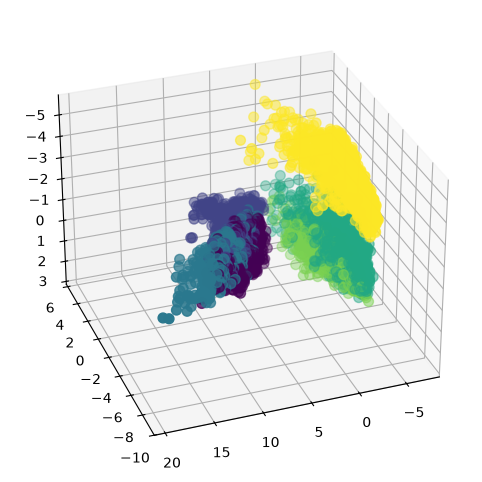

In [31]:
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(X_train)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=y_train,
    s=50,
)

Step 3: K-Means Clustering

    Apply the K-Means algorithm with n_clusters=6 on the 50D data.
    Visualize the resulting clusters on your 2D PCA projection.
    Report the Silhouette Score and the Inertia (Within-Cluster Sum of Squares).

Next, experiment with different values of k ranging from 2 to 12. Plot both the elbow curve (Inertia vs. k) and the Silhouette scores.


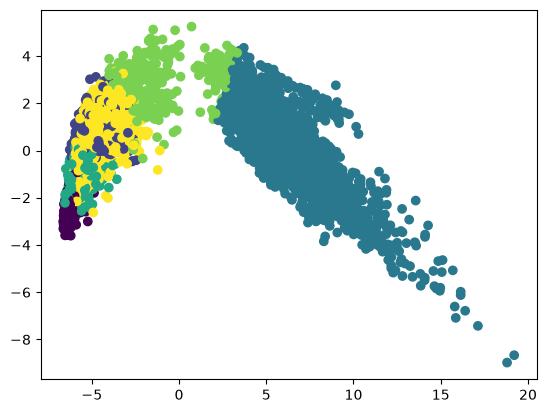

In [32]:
y_pred = KMeans(n_clusters=6, n_init=1, init='random', max_iter=1).fit_predict(X_reduced)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_pred,  marker="o")

Silhouette Score and Graphing:

For n_clusters = 2 The average silhouette_score is : 0.7008499225114799
Cluster 2 size: 4055 silhouette score: 0.6932548738740497


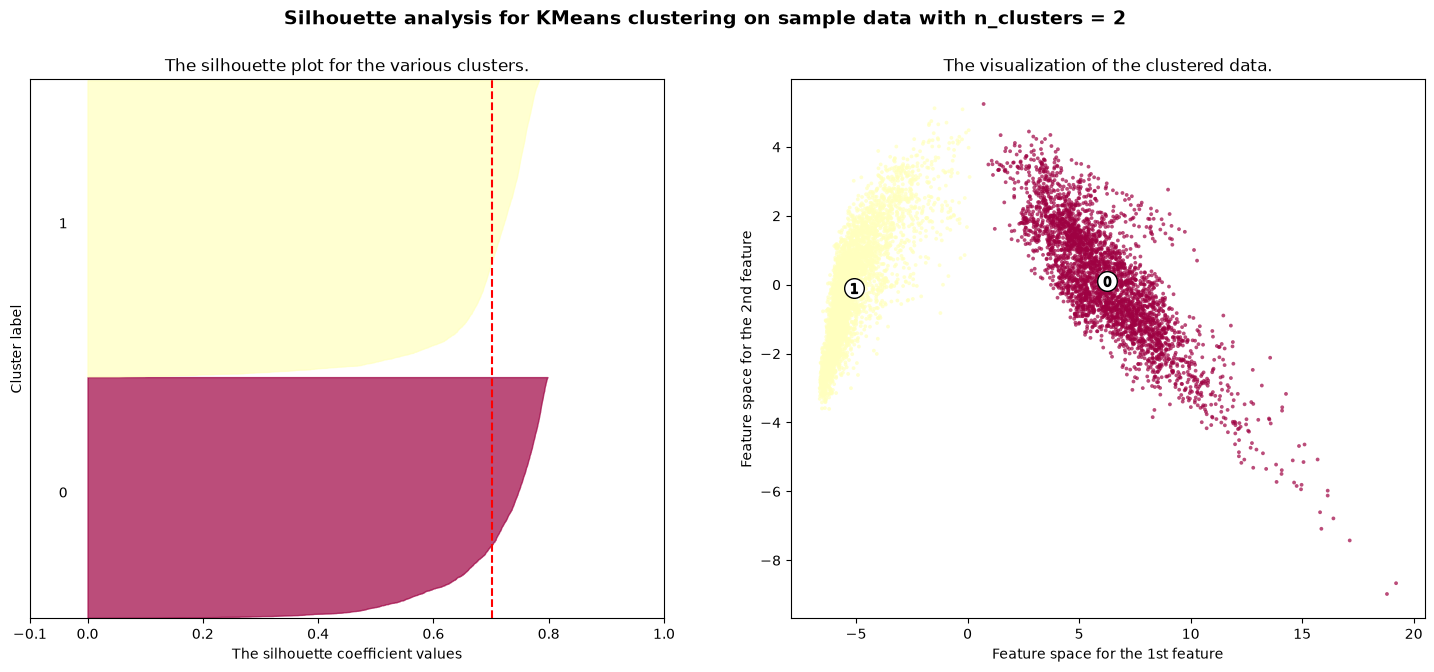

For n_clusters = 3 The average silhouette_score is : 0.5698480766661735
Cluster 3 size: 1358 silhouette score: 0.4447380543422307


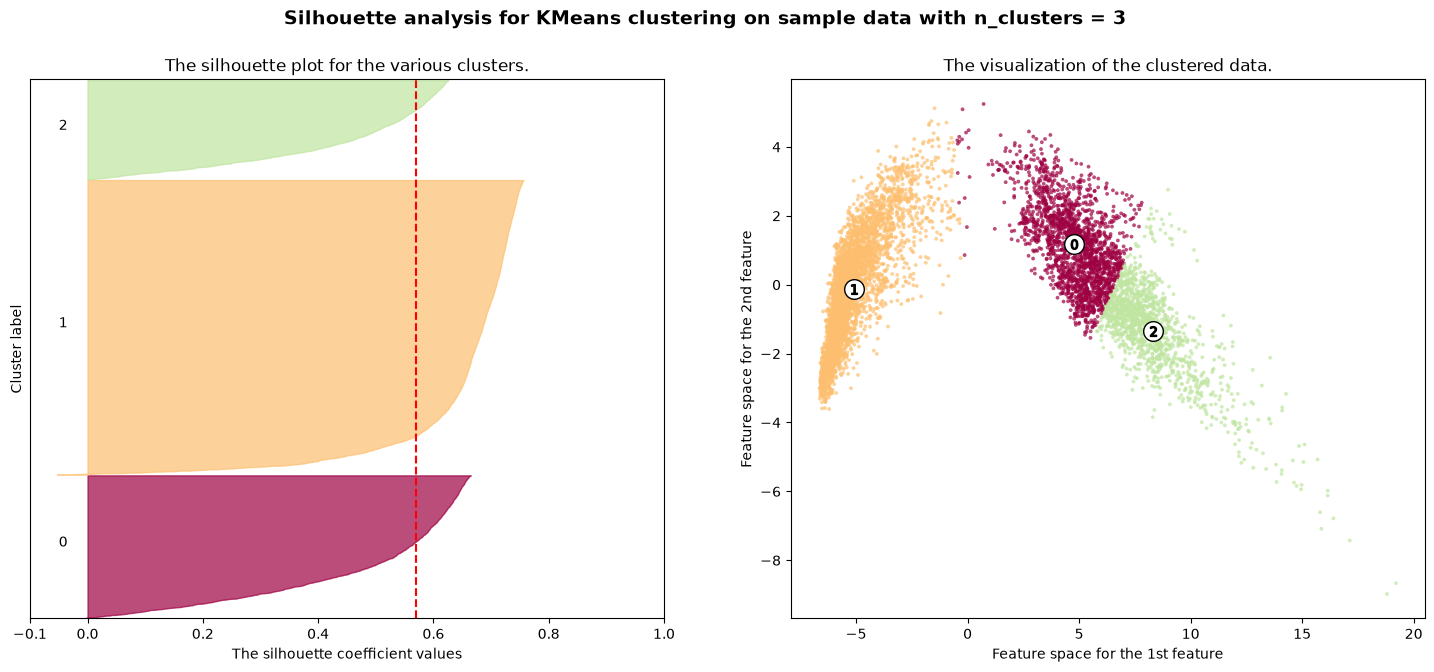

For n_clusters = 4 The average silhouette_score is : 0.4797572709975786
Cluster 4 size: 2590 silhouette score: 0.5037867329086511


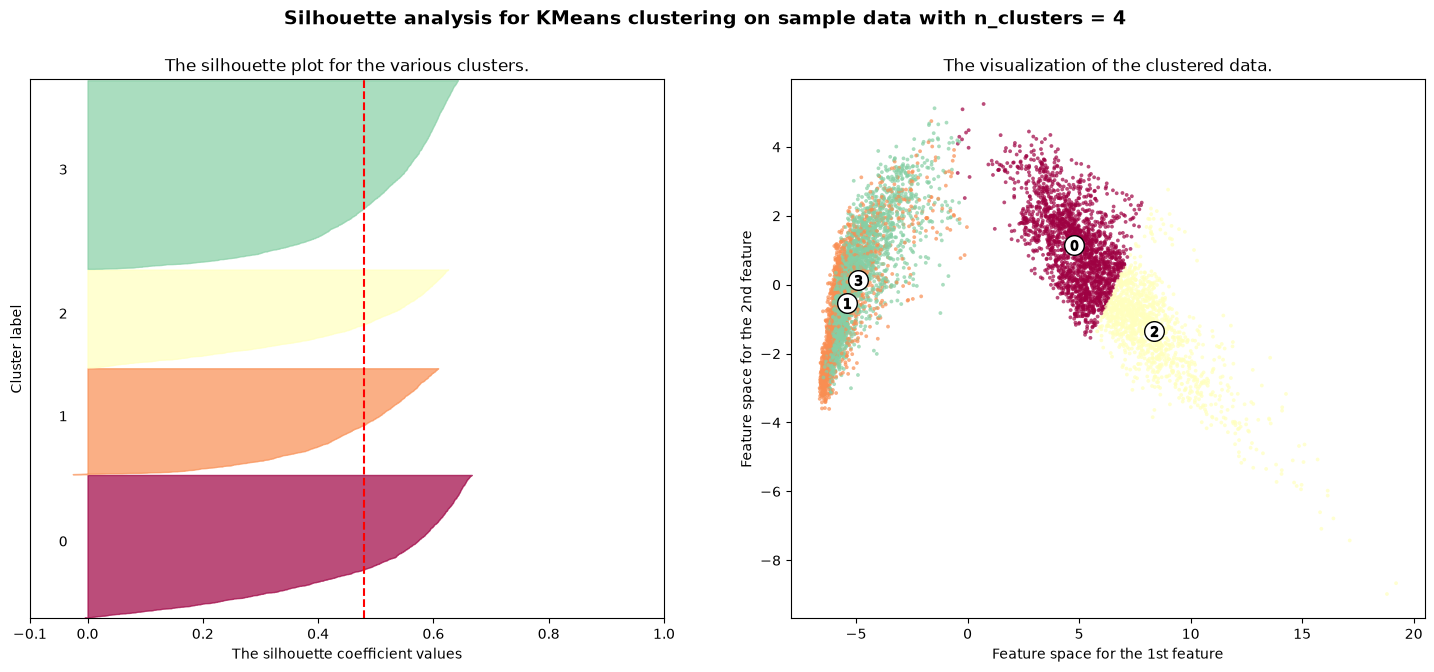

For n_clusters = 5 The average silhouette_score is : 0.4733552188764838
Cluster 5 size: 1922 silhouette score: 0.5630565003036213


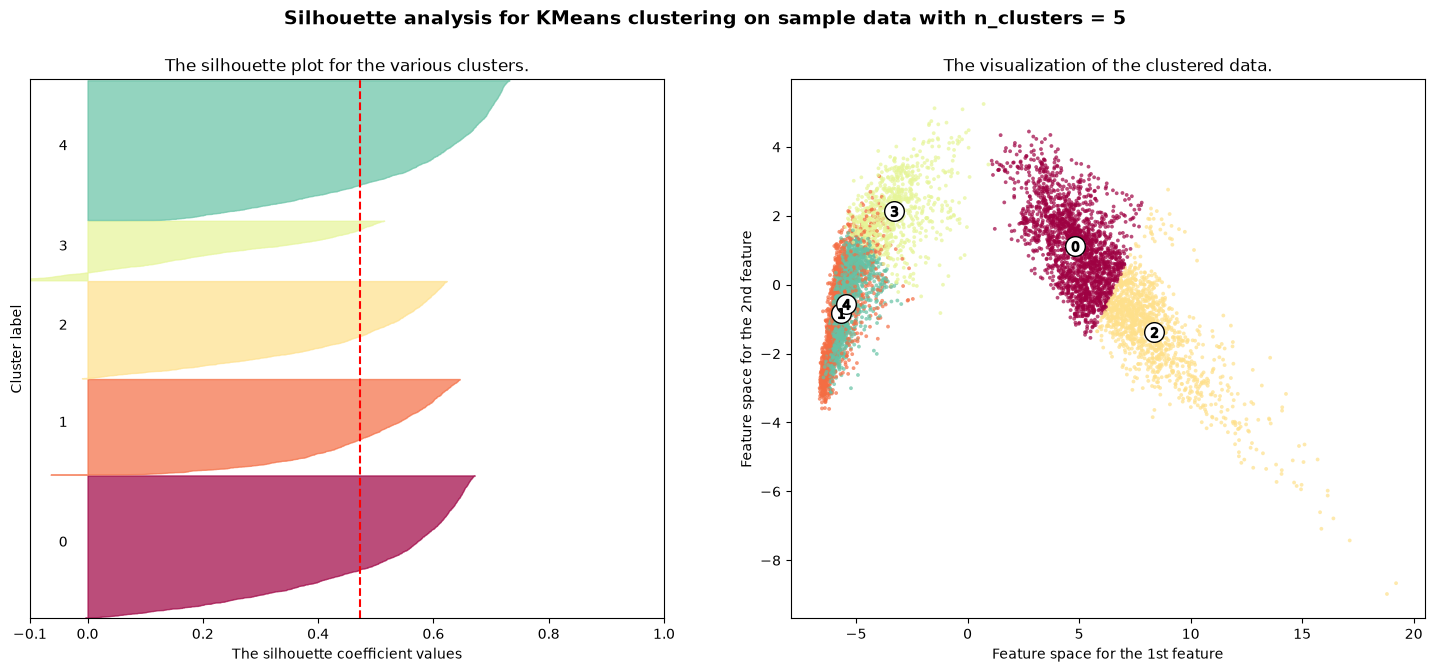

For n_clusters = 6 The average silhouette_score is : 0.4618832780316527
Cluster 6 size: 886 silhouette score: 0.5205581684416161


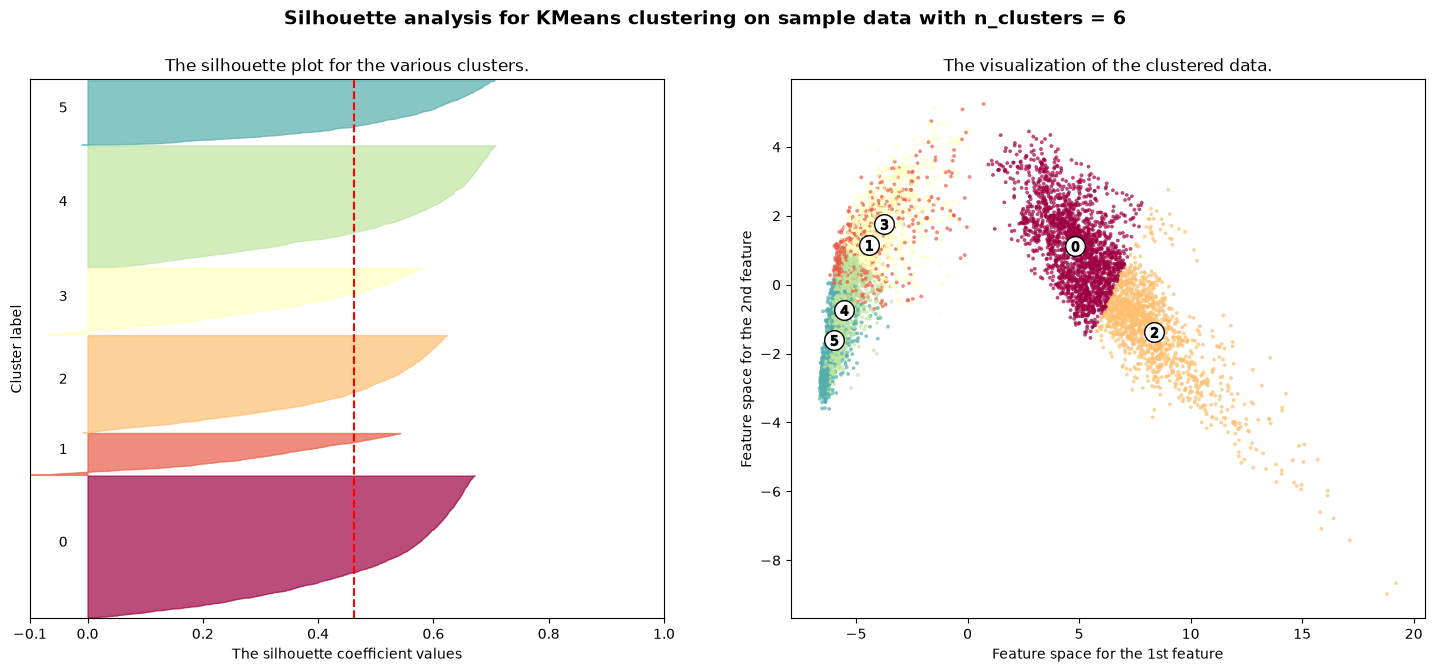

For n_clusters = 7 The average silhouette_score is : 0.438461837011354
Cluster 7 size: 1168 silhouette score: 0.4797479847340025


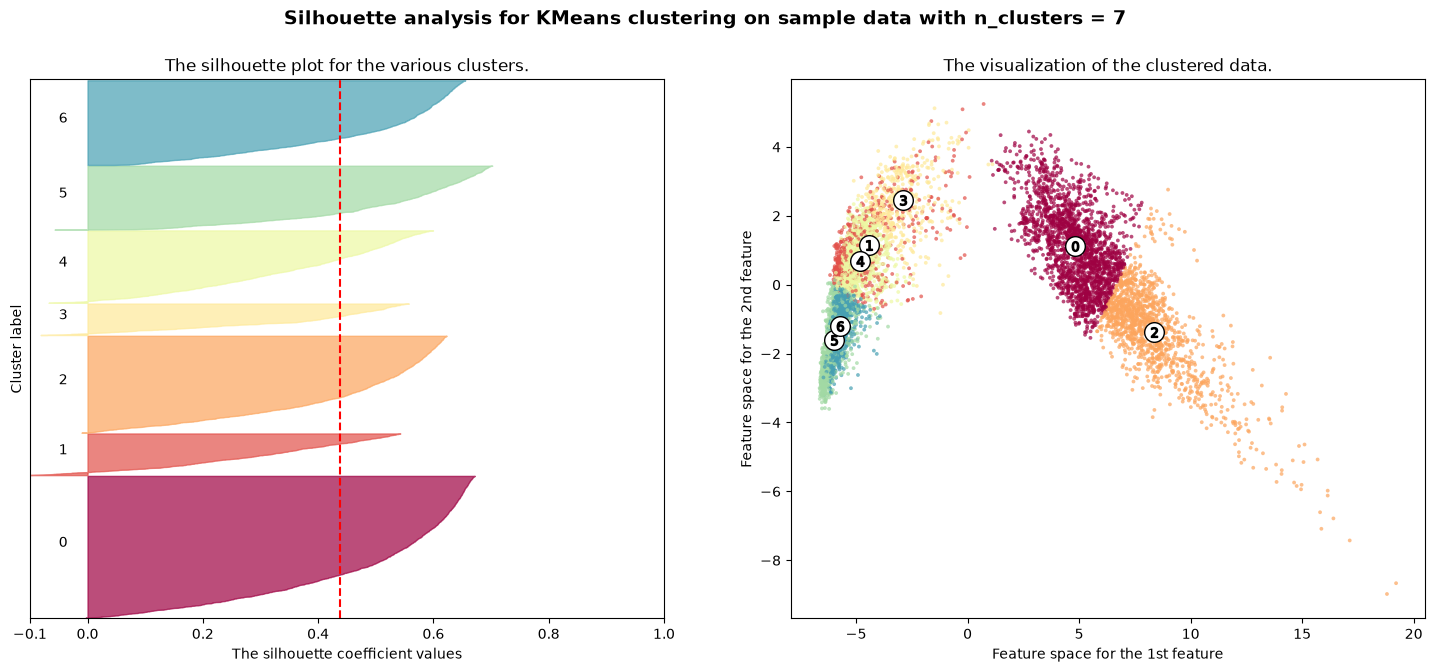

For n_clusters = 8 The average silhouette_score is : 0.40978708309747147
Cluster 8 size: 1518 silhouette score: 0.3880455252000222


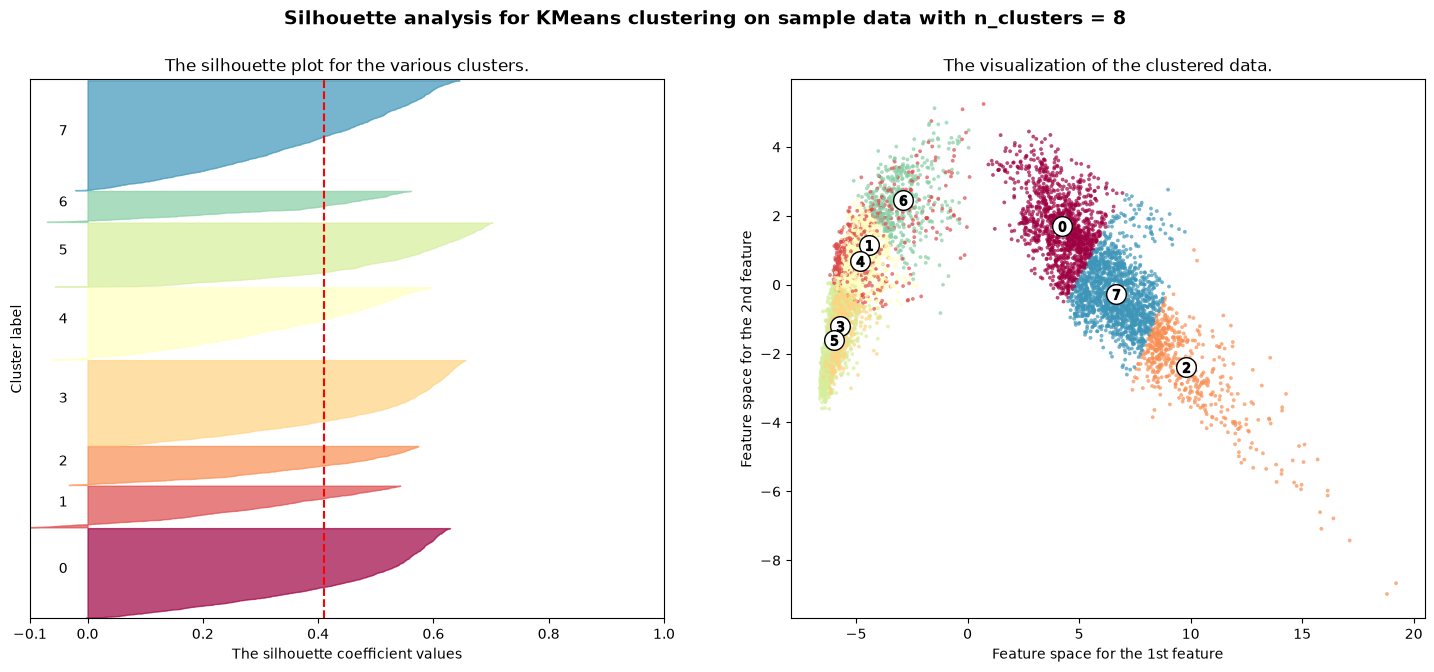

For n_clusters = 9 The average silhouette_score is : 0.40897960789983695
Cluster 9 size: 175 silhouette score: 0.34900558714522567


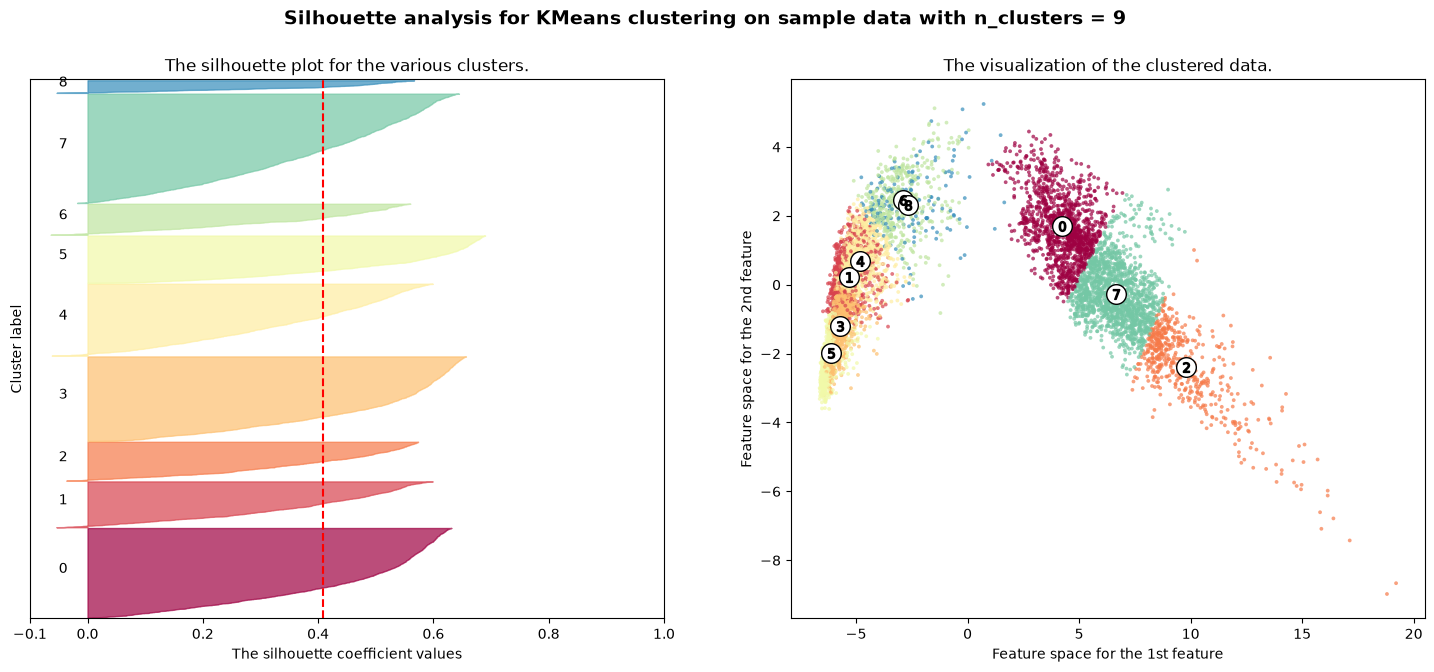

For n_clusters = 10 The average silhouette_score is : 0.3946934594629519
Cluster 10 size: 121 silhouette score: 0.3613697588295255


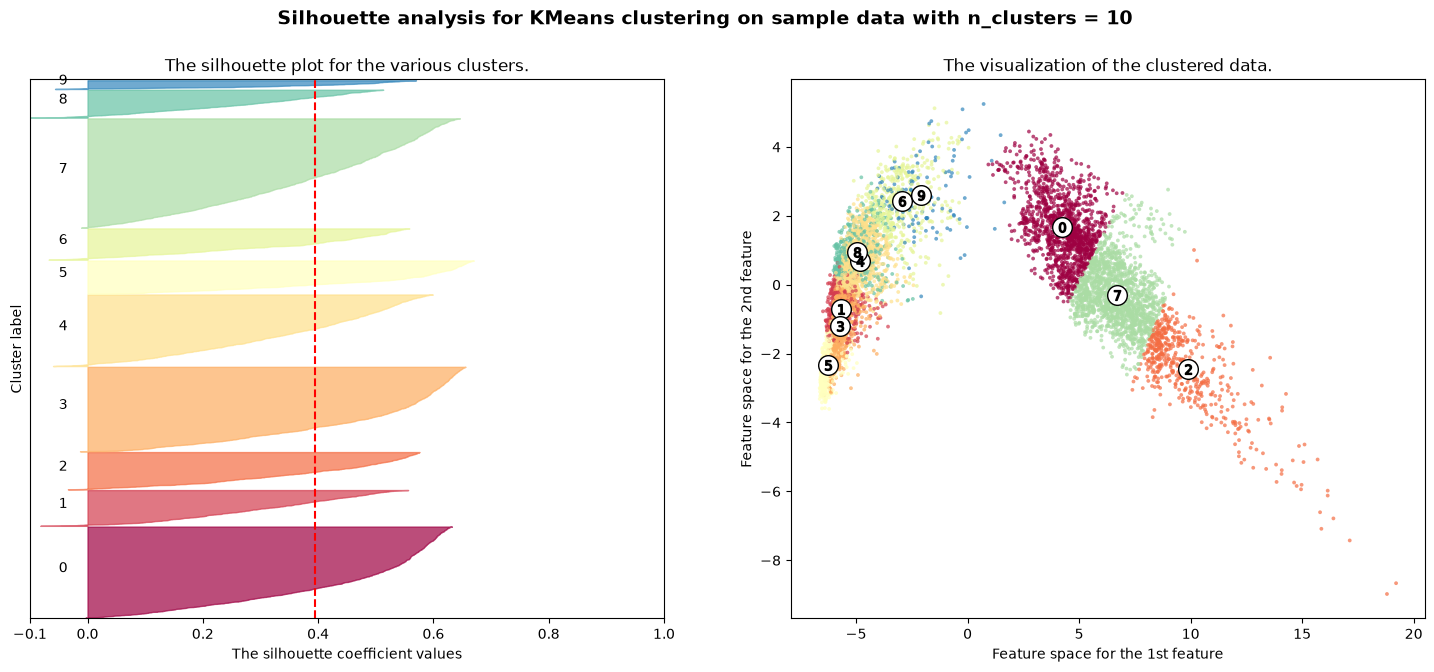

For n_clusters = 11 The average silhouette_score is : 0.38576393702233625
Cluster 11 size: 488 silhouette score: 0.30539588216154184


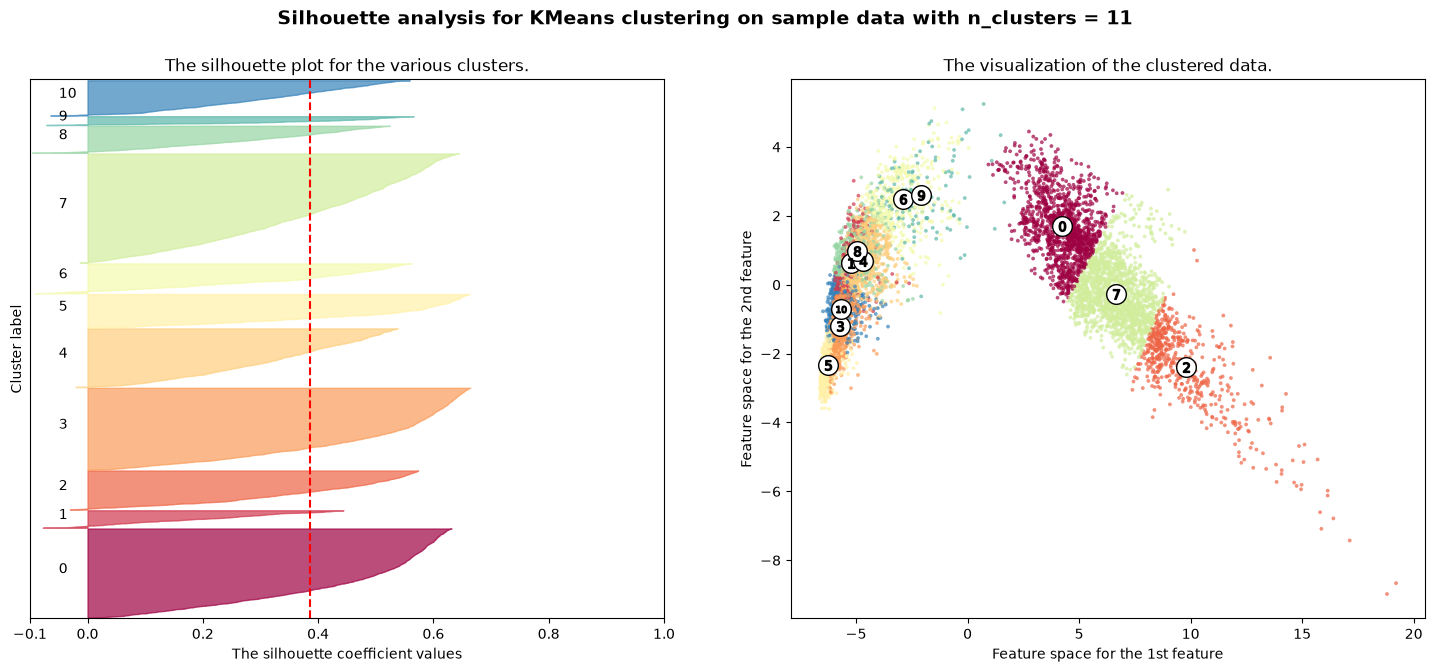

For n_clusters = 12 The average silhouette_score is : 0.37786877832692395
Cluster 12 size: 204 silhouette score: 0.41011607730408123


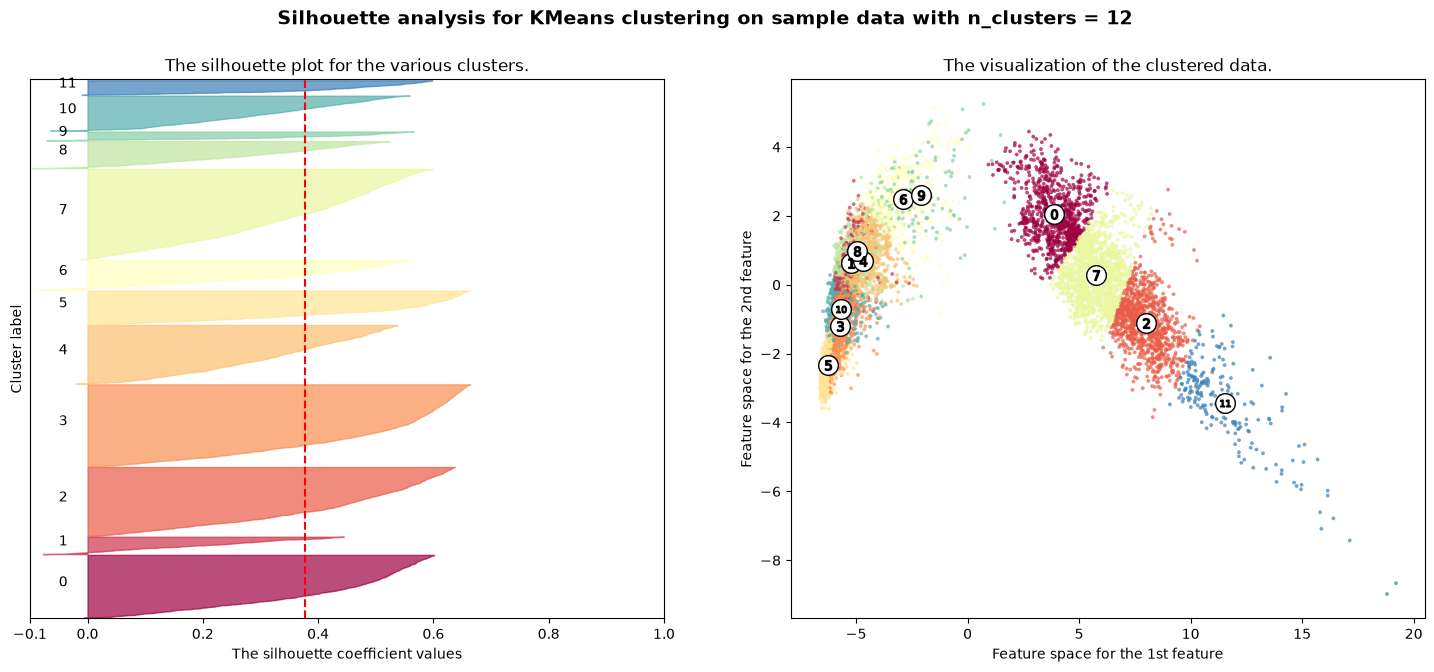

In [33]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


for n_clusters in range_n_clusters:
    # # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X_reduced) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X_reduced)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X_reduced, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X_reduced, cluster_labels)
    #print("silhouette scores for each samepl", sample_silhouette_values)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.Spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples
    print("Cluster", (i+1), "size:", size_cluster_i, "silhouette score:", ith_cluster_silhouette_values.mean())

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # # 2nd Plot showing the actual clusters formed
    colors = cm.Spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X_reduced[:, 0], X_reduced[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                c=colors, edgecolor='k')

    # # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=50, edgecolor='k')

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

    plt.show()

Inertia Values and Graphing:

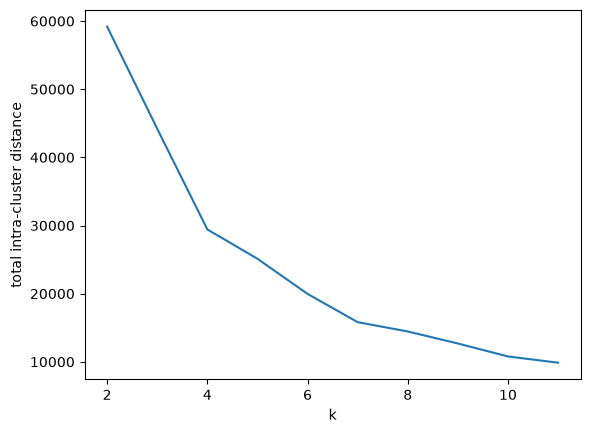

In [34]:
ks = range(2, 12)
scores = []

for k in ks:
    model = KMeans(n_clusters=k)
    model.fit_predict(X_reduced)
    scores.append(-model.score(X_reduced))

plt.plot(ks, scores)
plt.ylabel('total intra-cluster distance')
plt.xlabel('k')
plt.show()

Step 4: DBSCAN

    Apply DBSCAN on the 50D data, experimenting with different values for min_samples and eps (epsilon).
    Visualize the resulting clusters on your 2D PCA projection.
    Report the Silhouette Score for your best-performing hyperparameter combination.


In [35]:
def plot_clusters(X, labels, title):
    plt.figure(figsize=(7, 5))
    unique_labels = np.unique(labels)

    for label in unique_labels:
        mask = labels == label

        if label == -1:
            plt.scatter(X[mask, 0], X[mask, 1], marker='x', label='Noise (-1)')
        else:
            plt.scatter(X[mask, 0], X[mask, 1], label=f'Cluster {label}')

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()


def summarize_dbscan(labels):
    unique_labels = np.unique(labels)
    n_clusters = len([label for label in unique_labels if label != -1])
    n_noise = np.sum(labels == -1)

    print(f'Number of clusters, ignoring noise: {n_clusters}')
    print(f'Number of noise points: {n_noise}')
    print()
    print(pd.Series(labels).value_counts().sort_index())

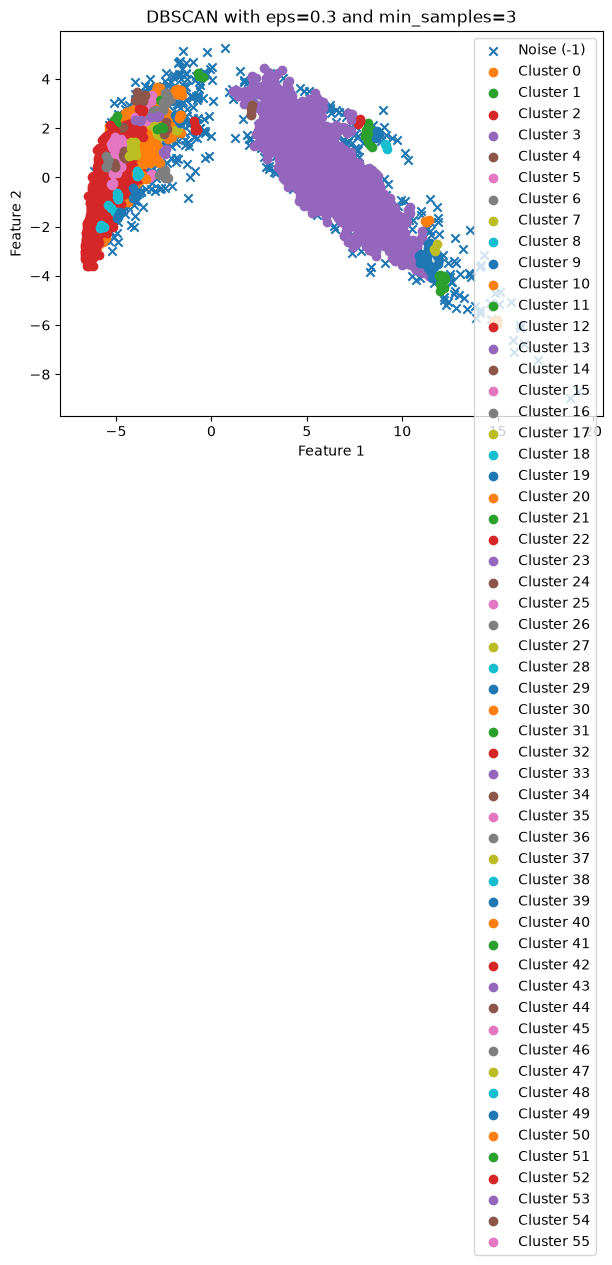

Number of clusters, ignoring noise: 56
Number of noise points: 544

-1      544
 0     2338
 1        3
 2     1159
 3     3046
 4        3
 5       23
 6        8
 7        5
 8        4
 9       21
 10       6
 11       3
 12       5
 13       4
 14       4
 15       5
 16       6
 17       4
 18       4
 19       3
 20       5
 21      11
 22       5
 23       6
 24       3
 25       4
 26       4
 27       3
 28       3
 29       4
 30       4
 31      12
 32       4
 33       4
 34       8
 35       4
 36       3
 37       7
 38       3
 39       3
 40       3
 41       3
 42       3
 43       4
 44       4
 45       4
 46       4
 47       4
 48       3
 49       3
 50       3
 51       3
 52       3
 53       3
 54       4
 55       3
Name: count, dtype: int64


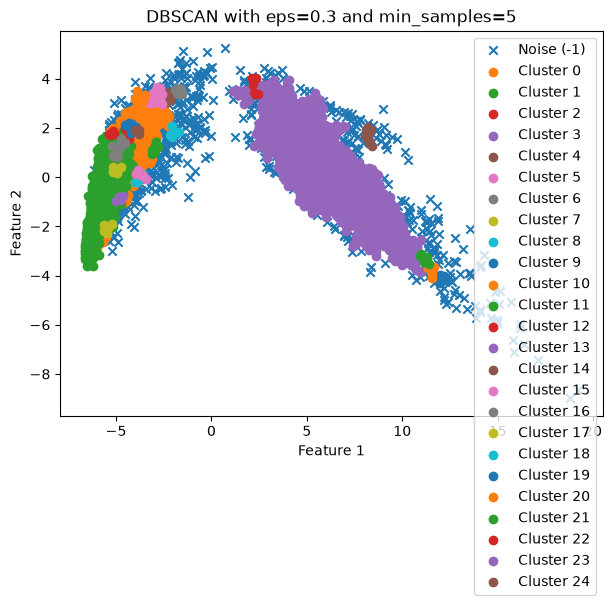

Number of clusters, ignoring noise: 25
Number of noise points: 856

-1      856
 0     2233
 1     1095
 2        4
 3     2986
 4        8
 5       31
 6        6
 7        6
 8        5
 9        9
 10       5
 11       9
 12       5
 13       4
 14      11
 15       5
 16      12
 17       5
 18       5
 19       8
 20       8
 21       7
 22      10
 23      15
 24       4
Name: count, dtype: int64


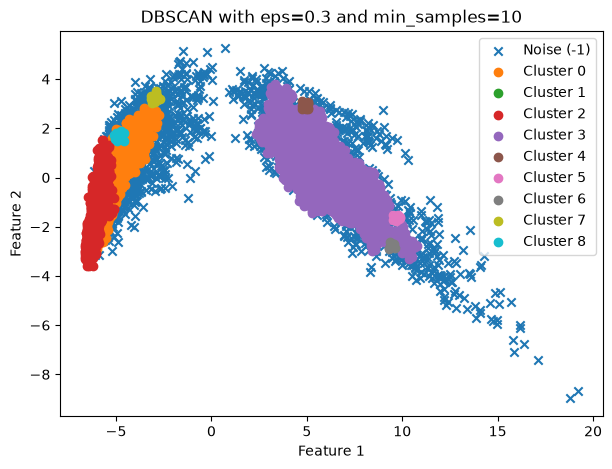

Number of clusters, ignoring noise: 9
Number of noise points: 1612

-1    1612
 0    1994
 1      14
 2     927
 3    2747
 4      13
 5       9
 6       8
 7      14
 8      14
Name: count, dtype: int64


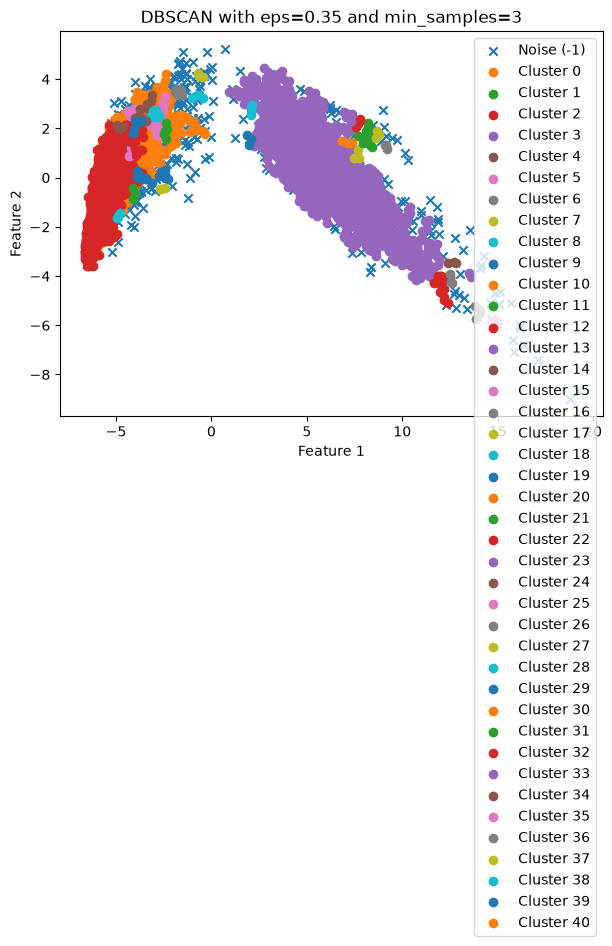

Number of clusters, ignoring noise: 41
Number of noise points: 362

-1      362
 0     2445
 1        5
 2     1251
 3     3102
 4        3
 5       13
 6        6
 7        3
 8        3
 9        6
 10       4
 11       3
 12      17
 13       6
 14       4
 15       4
 16       3
 17       3
 18       7
 19       7
 20       3
 21      15
 22       5
 23       6
 24       5
 25       7
 26       3
 27       3
 28       3
 29       5
 30       3
 31       5
 32       6
 33       3
 34       3
 35       3
 36       4
 37       3
 38       4
 39       3
 40       3
Name: count, dtype: int64


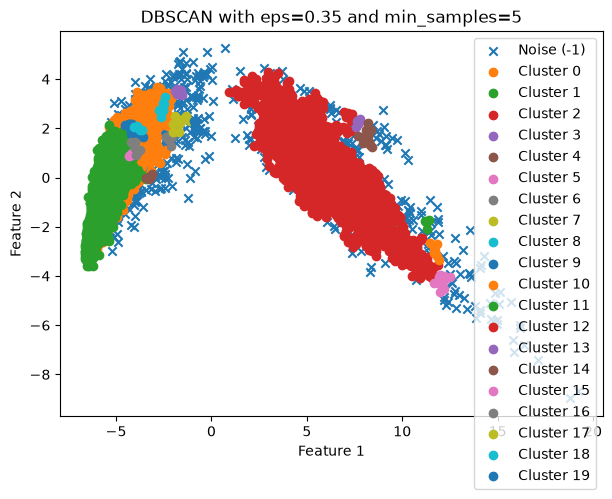

Number of clusters, ignoring noise: 20
Number of noise points: 564

-1      564
 0     2386
 1     1205
 2     3080
 3        6
 4        5
 5       13
 6        5
 7        7
 8        7
 9       15
 10       7
 11       5
 12       6
 13       5
 14      15
 15       5
 16       5
 17       2
 18       4
 19       5
Name: count, dtype: int64


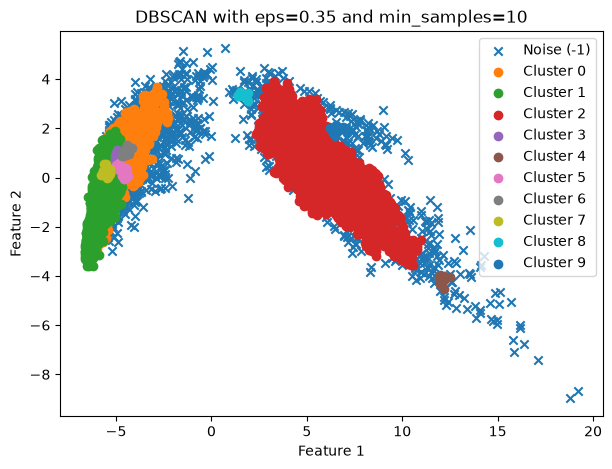

Number of clusters, ignoring noise: 10
Number of noise points: 1050

-1    1050
 0    2226
 1    1043
 2    2944
 3      10
 4      10
 5      23
 6      11
 7      11
 8      10
 9      14
Name: count, dtype: int64


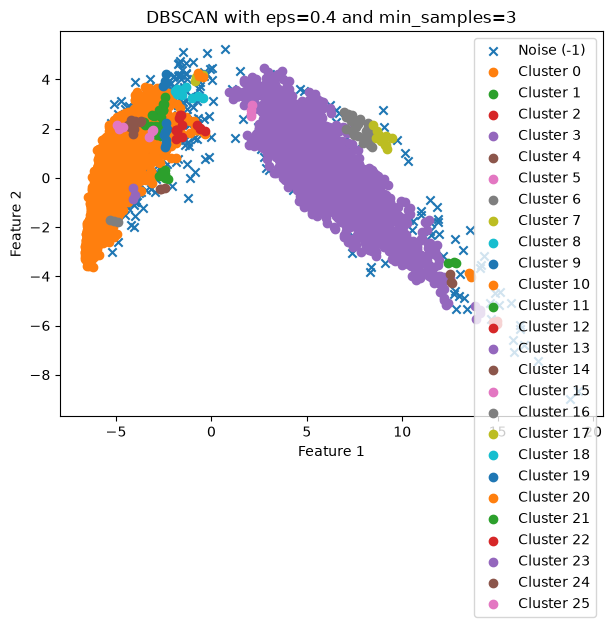

Number of clusters, ignoring noise: 26
Number of noise points: 265

-1      265
 0     3788
 1       17
 2        4
 3     3153
 4        8
 5        3
 6        3
 7        3
 8        7
 9        7
 10       3
 11       6
 12      10
 13       3
 14       3
 15       3
 16      30
 17      10
 18       3
 19       3
 20       3
 21       3
 22       3
 23       4
 24       3
 25       4
Name: count, dtype: int64


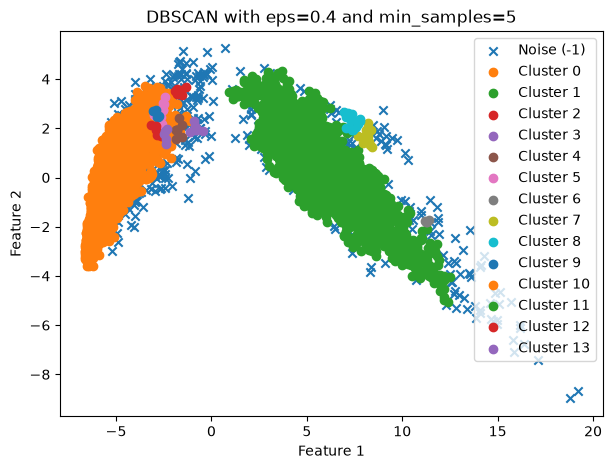

Number of clusters, ignoring noise: 14
Number of noise points: 397

-1      397
 0     3739
 1     3128
 2        7
 3        7
 4        8
 5        9
 6        4
 7       15
 8       14
 9        5
 10       5
 11       4
 12       5
 13       5
Name: count, dtype: int64


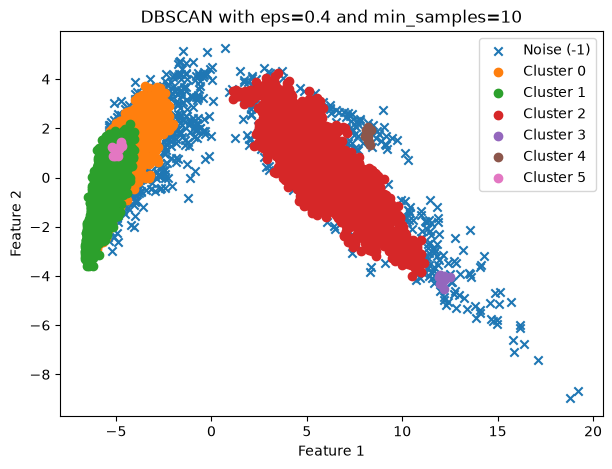

Number of clusters, ignoring noise: 6
Number of noise points: 747

-1     747
 0    2351
 1    1163
 2    3060
 3      10
 4      11
 5      10
Name: count, dtype: int64


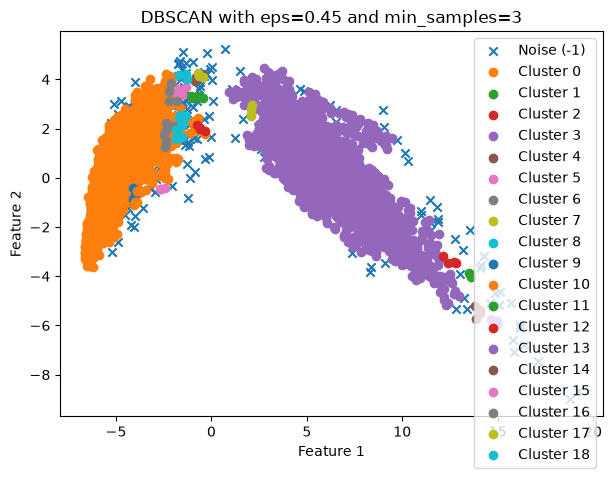

Number of clusters, ignoring noise: 19
Number of noise points: 187

-1      187
 0     3874
 1        4
 2        4
 3     3214
 4        3
 5        7
 6        8
 7        3
 8       12
 9        3
 10       4
 11       3
 12       4
 13       4
 14       4
 15       3
 16       4
 17       4
 18       3
Name: count, dtype: int64


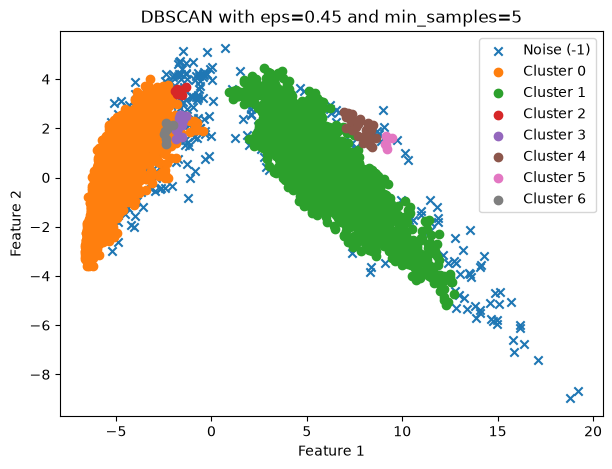

Number of clusters, ignoring noise: 7
Number of noise points: 282

-1     282
 0    3846
 1    3162
 2       7
 3      12
 4      31
 5       5
 6       7
Name: count, dtype: int64


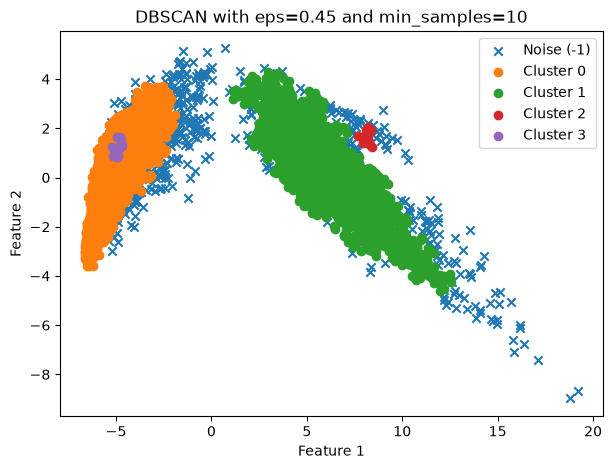

Number of clusters, ignoring noise: 4
Number of noise points: 569

-1     569
 0    3637
 1    3118
 2      14
 3      14
Name: count, dtype: int64


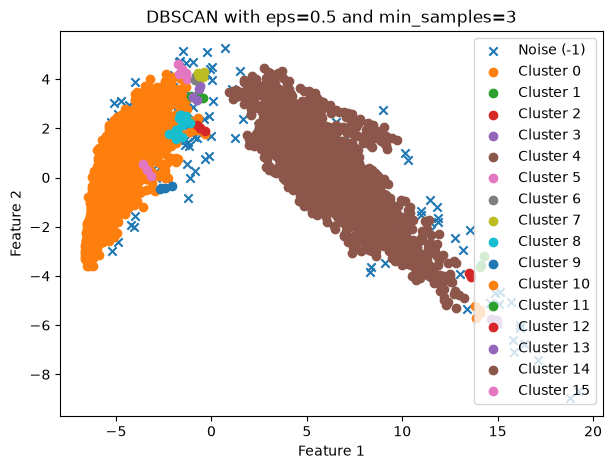

Number of clusters, ignoring noise: 16
Number of noise points: 118

-1      118
 0     3937
 1        4
 2        4
 3        4
 4     3233
 5        6
 6        3
 7        4
 8       14
 9        4
 10       4
 11       3
 12       3
 13       4
 14       4
 15       3
Name: count, dtype: int64


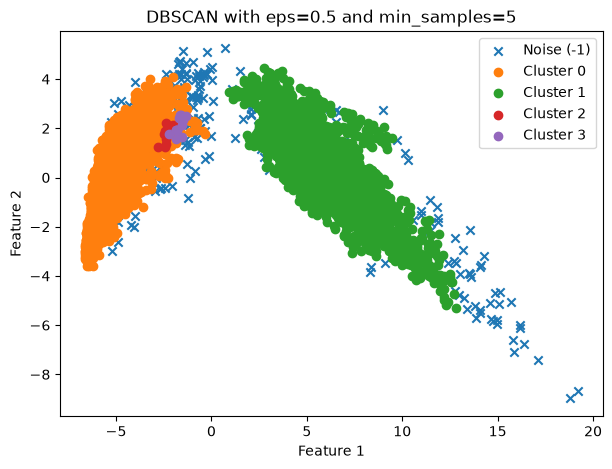

Number of clusters, ignoring noise: 4
Number of noise points: 209

-1     209
 0    3903
 1    3218
 2       9
 3      13
Name: count, dtype: int64


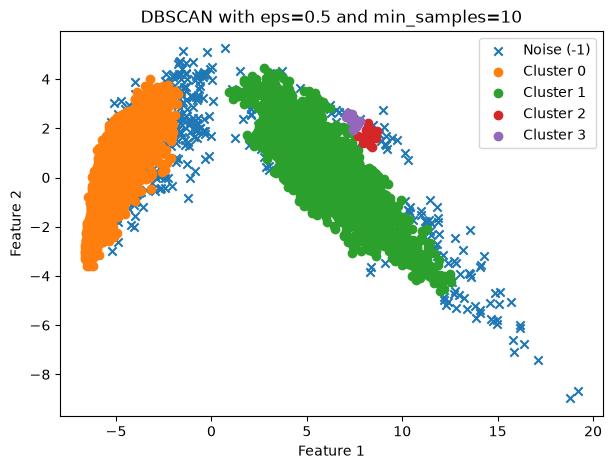

Number of clusters, ignoring noise: 4
Number of noise points: 419

-1     419
 0    3760
 1    3146
 2      17
 3      10
Name: count, dtype: int64
    silhouette_ignoring_noise   eps  min_samples  n_clusters  n_noise  \
14                   0.436998  0.50           10           4      419   
13                   0.435325  0.50            5           4      209   
8                    0.269732  0.40           10           6      747   
10                   0.180583  0.45            5           7      282   
11                   0.104563  0.45           10           4      569   
12                   0.090550  0.50            3          16      118   
4                    0.084750  0.35            5          20      564   
7                    0.065901  0.40            5          14      397   
2                    0.029095  0.30           10           9     1612   
9                    0.023966  0.45            3          19      187   
5                    0.019187  0.35           10 

In [58]:
results = []

for eps in [0.3, 0.35, 0.4, 0.45, 0.5]:
    for min_samples in [3, 5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_reduced)

        plot_clusters(X_reduced, labels, f'DBSCAN with eps={eps} and min_samples={min_samples}')
        summarize_dbscan(labels)

        n_clusters = len([label for label in np.unique(labels) if label != -1])
        n_noise = np.sum(labels == -1)
        noise_pct = n_noise / len(labels)

        sil = np.nan
        mask = labels != -1

        if np.sum(mask) > 0:
            labels_no_noise = labels[mask]
            X_no_noise = X_reduced[mask]
            n_clusters_no_noise = len(set(labels_no_noise))

            if n_clusters_no_noise >= 2 and n_clusters_no_noise < len(labels_no_noise):
                sil = silhouette_score(X_no_noise, labels_no_noise)

        results.append({
            'silhouette_ignoring_noise': sil,
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': noise_pct
        })

print(pd.DataFrame(results).sort_values(by='silhouette_ignoring_noise', ascending=False))

Our best silhouette score is 0.436998 with an epsilon of 0.50 and 10 min_samples.

Step 6: Evaluation and Reflection

Answer the following questions:

    Which algorithm produced more coherent clusters?
    Did dimensionality reduction improve your clustering results or execution time?
    How accurately did the unsupervised clusters map to the true activity labels?
    If you did not have access to the ground-truth labels, how would you determine the optimal number of clusters and evaluate your model's success?

K Means Clustering with the silhouette scores produced the most coherent clusters because they gave much more readable groupings. Dimensionality reduction granted substantial reduction in execution time on the production of graphs when compared with trying to parse the information. The clustered results were also much more readable and cleanly grouped. The unsupervised clusters weren't very accurate when mapping to the true activity labels. The best silhouette scores produced were still below 0.50 and the results weren't accurate. I would use the elbow graph produced and look for where the cluster number hits a point of diminishing returns to note where the approximate number of optimal clusters is.
